# Ngày 4 - Từ 17 cái chấm của bạn đến một model pose

Notebook này chạy **sau** khi nhãn của bạn đã qua cổng gold (`tools/evaluate_pose_annotations.py`).
Trình tự: kiểm nhãn -> đo model gốc -> fine-tune trên nhãn của bạn -> đo lại -> nhìn tận mắt.

## Hợp đồng chạy

- Chọn **một** cách đưa bài của bạn lên Colab: clone fork GitHub ở cell 0 (khuyến nghị), hoặc upload/mount thư mục `Day4-Lab/`.
- Nếu clone fork: push `dataset/labels/train/`, `annotations/`, `reports/`, `outputs/` và `GUIDELINE_MINI.md` lên **fork của bạn** trước.
- **Không** upload protected reference. Nếu bạn có `gold/`, nó cũng không được dùng để train.
- Chạy từ trên xuống. Không đổi `val` trong `data.yaml` sang tập train để làm đẹp số.
- 20 ảnh là quá ít để ra một model dùng được. Cái bạn đo hôm nay là **vòng lặp dữ liệu**,
  không phải chất lượng sản phẩm. Con số quan trọng là *chênh lệch* giữa trước và sau fine-tune.


## 0. Đưa fork của bạn vào Colab (khuyến nghị)

Dán URL HTTPS của **fork có nhãn của bạn** vào `REPO_URL`, rồi chạy cell dưới. Cell này không xoá hoặc ghi đè thư mục nào.

Nếu bạn đã upload/mount `Day4-Lab/`, để `REPO_URL` trống và chạy cell dưới để bỏ qua bước clone.

In [1]:
import subprocess
from pathlib import Path

# Ví dụ: https://github.com/ten-github-cua-ban/Day4-KeypointPose-Student.git
# Để trống nếu bạn upload/mount thư mục Day4-Lab thay vì clone fork.
REPO_URL = ""
WORKDIR = Path('/content') if Path('/content').is_dir() else Path.cwd()
LAB_ROOT = WORKDIR / 'Day4-Lab'

if REPO_URL.strip():
    if '<' in REPO_URL or '>' in REPO_URL:
        raise ValueError('Hãy thay REPO_URL bằng URL HTTPS của fork GitHub của bạn.')
    if (LAB_ROOT / 'data.yaml').is_file():
        print(f'Đã có repo tại {LAB_ROOT}; dùng bản hiện có.')
    elif LAB_ROOT.exists():
        raise RuntimeError(f'{LAB_ROOT} đã tồn tại nhưng không phải repo Day 4 hợp lệ. Đổi tên hoặc xoá thủ công rồi chạy lại.')
    else:
        subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(LAB_ROOT)], check=True)
        print(f'Đã clone fork vào {LAB_ROOT}')
else:
    print('Bỏ qua clone. Hãy upload hoặc mount thư mục Day4-Lab trước khi chạy cell kế tiếp.')


Bỏ qua clone. Hãy upload hoặc mount thư mục Day4-Lab trước khi chạy cell kế tiếp.


In [2]:
%pip -q install -U ultralytics

import json
import sys
from pathlib import Path

import torch
import yaml
from ultralytics import YOLO

# Cell 0 đã đặt LAB_ROOT khi bạn clone fork. Với upload/mount, đặt đúng đường dẫn ở đây.
LAB_ROOT = globals().get('LAB_ROOT', Path('/content/Day4-Lab'))
if not (LAB_ROOT / 'data.yaml').is_file():
    LAB_ROOT = Path.cwd() if (Path.cwd() / 'data.yaml').exists() else Path.cwd().parent
assert (LAB_ROOT / 'data.yaml').exists(), f'Không thấy data.yaml trong {LAB_ROOT}'

TRAIN_IMAGES = LAB_ROOT / 'dataset/images/train'
TRAIN_LABELS = LAB_ROOT / 'dataset/labels/train'
TEST_IMAGES = LAB_ROOT / 'dataset/images/test'
TEST_LABELS = LAB_ROOT / 'dataset/labels/test'
OUTPUTS = LAB_ROOT / 'outputs'
RUNS = OUTPUTS / 'runs'
OUTPUTS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(LAB_ROOT / 'tools'))

# Sinh data_colab.yaml trỏ 'path' vào đúng nơi vừa upload. File data.yaml gốc
# trong repo giữ nguyên, nên bạn commit lại mà không bị lệch đường dẫn.
config = yaml.safe_load((LAB_ROOT / 'data.yaml').read_text())
config['path'] = str(LAB_ROOT)
DATA_YAML = LAB_ROOT / 'data_colab.yaml'
DATA_YAML.write_text(yaml.safe_dump(config, sort_keys=False, allow_unicode=True))

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
MODEL_NAME = 'yolo26n-pose.pt'   # đổi sang 'yolo11n-pose.pt' nếu muốn so hai thế hệ
print('LAB_ROOT :', LAB_ROOT)
print('device   :', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE == 0 else 'CPU - sẽ chậm')
print('kpt_shape:', config['kpt_shape'], '| flip_idx:', config['flip_idx'])
assert config['kpt_shape'] == [17, 3], 'kpt_shape phải là [17, 3], nếu không cờ visibility đã bị vứt'



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
LAB_ROOT : /Users/tungdao1998/github/Day4-KeypointPose-Student
device   : cpu | CPU - sẽ chậm
kpt_shape: [17, 3] | flip_idx: [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15]


## 1. Kiểm nhãn trước khi train

Chạy đúng script bạn đã chạy ở local: 56 số một dòng, cờ chỉ nhận 0/1/2, đủ file cho từng ảnh.
Một file nhãn hỏng ở đây sẽ thành một model hỏng ở dưới, mà không có dòng cảnh báo nào.


In [3]:
import subprocess

result = subprocess.run(
    [sys.executable, str(LAB_ROOT / 'tools/check_pose_labels.py'),
     '--images', str(TRAIN_IMAGES), '--labels', str(TRAIN_LABELS)],
    capture_output=True, text=True)
print(result.stdout or result.stderr)
assert result.returncode == 0, 'Nhãn train chưa đạt định dạng - sửa trước khi train'

from poselib import parse_yolo_pose_file

def count(label_dir):
    files = sorted(label_dir.glob('*.txt'))
    people = [p for f in files for p in parse_yolo_pose_file(f)]
    flags = [v for p in people for _, _, v in p.keypoints]
    return len(files), len(people), flags.count(2), flags.count(1), flags.count(0)

for name, directory in (('train (nhãn của bạn)', TRAIN_LABELS), ('test  (nhãn phát sẵn)', TEST_LABELS)):
    files, people, v2, v1, v0 = count(directory)
    print(f'{name}: {files} file, {people} skeleton, v=2 {v2}, v=1 {v1}, v=0 {v0}')


Đã đọc 20/20 file nhãn, 29 skeleton.
Cờ visibility: v=2 336 | v=1 55 | v=0 102

CẢNH BÁO (12) - không chặn nộp, nhưng phải xem lại:
- train_02.txt:1: có 5 khớp v=0 trong khi cả người nằm gọn giữa ảnh. Khớp không ra khỏi khung được thì phải là v=1 (bị che, vẫn đặt chấm), không phải v=0
- train_03.txt:2: có 4 khớp v=0 trong khi cả người nằm gọn giữa ảnh. Khớp không ra khỏi khung được thì phải là v=1 (bị che, vẫn đặt chấm), không phải v=0
- train_06.txt:1: có 5 khớp v=0 trong khi cả người nằm gọn giữa ảnh. Khớp không ra khỏi khung được thì phải là v=1 (bị che, vẫn đặt chấm), không phải v=0
- train_08.txt:1: left_shoulder/right_shoulder nằm ngược chiều so với hai mắt - dấu hiệu đảo trái/phải, mở tools/visualize_pose.py xem lại
- train_08.txt:1: left_hip/right_hip nằm ngược chiều so với hai mắt - dấu hiệu đảo trái/phải, mở tools/visualize_pose.py xem lại
- train_09.txt:1: có 7 khớp v=0 trong khi cả người nằm gọn giữa ảnh. Khớp không ra khỏi khung được thì phải là v=1 (bị che, vẫn đặt chấm),

## 2. Model gốc, chưa học gì từ nhãn của bạn

`yolo26n-pose.pt` đã được train sẵn trên COCO - tức là nó **đã biết** bộ 17 điểm này.
Đo nó trên tập test trước, để lát nữa có mốc mà so. Đây là baseline, không phải đối thủ.


In [4]:
baseline_model = YOLO(MODEL_NAME)
baseline_metrics = baseline_model.val(
    data=str(DATA_YAML), split='val', device=DEVICE, plots=False,
    project=str(RUNS), name='baseline', exist_ok=True)

def summarize(metrics):
    return {
        'pose_mAP50': round(float(metrics.pose.map50), 4),
        'pose_mAP50_95': round(float(metrics.pose.map), 4),
        'pose_precision': round(float(metrics.pose.mp), 4),
        'pose_recall': round(float(metrics.pose.mr), 4),
        'box_mAP50': round(float(metrics.box.map50), 4),
        'box_mAP50_95': round(float(metrics.box.map), 4),
    }

baseline = summarize(baseline_metrics)
print(json.dumps(baseline, indent=2))


Ultralytics 8.4.153 🚀 Python-3.8.18 torch-2.2.2 CPU (Intel Core i7-9750H 2.60GHz)
YOLO26n-pose summary (fused): 129 layers, 2,926,494 parameters, 0 gradients, 7.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 196.6±68.8 MB/s, size: 91.1 KB)
val: Scanning /Users/tungdao1998/github/Day4-KeypointPose-Student/dataset/labels/test.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 1.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.5s/it 2.5s
                   all         10         13      0.995      0.923      0.979      0.812      0.973      0.846      0.845      0.685
Speed: 4.1ms preprocess, 234.0ms inference, 0.0ms loss, 1.8ms postprocess per image
{
  "pose_mAP50": 0.845,
  "pose_mAP50_95": 0.6853,
  "pose_precision": 0.9734,
  "pose_recall": 0.8462,
  "box_mAP50": 0.9785,
  "box_mAP50_95": 0.8119
}


## 3. Fine-tune trên nhãn của bạn

`fliplr=0.5` là augmentation lật ảnh ngang. Ultralytics đọc `flip_idx` trong `data.yaml`
để đổi tên khớp trái/phải cho ảnh lật. Đây chính là slide 15: nếu nhãn của bạn đảo trái/phải,
model được dạy cái sai đó **hai lần** - một lần ở ảnh gốc, một lần ở ảnh lật.

Muốn thấy tận mắt: chạy lại cell này với `fliplr=0.0` và so `pose_mAP50-95`.


In [ ]:
model = YOLO(MODEL_NAME)
train_result = model.train(
    data=str(DATA_YAML),
    epochs=80,
    imgsz=640,
    batch=8,
    device=DEVICE,
    workers=2,
    project=str(RUNS),
    name='pose_finetune',
    exist_ok=True,
    seed=20260915,
    fliplr=0.5,
    plots=True,
    patience=30,
)
BEST = Path(model.trainer.best)
print('checkpoint tốt nhất:', BEST)


Ultralytics 8.4.153 🚀 Python-3.8.18 torch-2.2.2 CPU (Intel Core i7-9750H 2.60GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/tungdao1998/github/Day4-KeypointPose-Student/data_colab.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pose_

## 4. Đánh giá trên đúng tập test

`data.yaml` trỏ `val` tới 10 ảnh test đã có nhãn phát sẵn. Không đổi nó sang train.

`pose_mAP` chấm bằng **OKS** - đúng thước đo bạn đã dùng để chấm nhãn của mình ở
`tools/evaluate_pose_annotations.py`. Cùng một công thức, một bên đo người, một bên đo model.


In [ ]:
best_model = YOLO(str(BEST))
finetuned_metrics = best_model.val(
    data=str(DATA_YAML), split='val', device=DEVICE, plots=True,
    project=str(RUNS), name='pose_eval', exist_ok=True)
finetuned = summarize(finetuned_metrics)

comparison = {'baseline_' + MODEL_NAME.replace('.pt', ''): baseline, 'finetuned': finetuned,
              'delta': {k: round(finetuned[k] - baseline[k], 4) for k in baseline}}
(OUTPUTS / 'eval_model.json').write_text(json.dumps(comparison, ensure_ascii=False, indent=2))

header = f"{'chỉ số':<16}{'gốc':>10}{'sau fine-tune':>16}{'chênh':>10}"
print(header); print('-' * len(header))
for key in baseline:
    print(f'{key:<16}{baseline[key]:>10.4f}{finetuned[key]:>16.4f}{comparison["delta"][key]:>+10.4f}')
print('\nĐã ghi outputs/eval_model.json')


Ultralytics 8.4.153 🚀 Python-3.8.18 torch-2.2.2 CPU (Intel Core i7-9750H 2.60GHz)
YOLO26n-pose summary (fused): 129 layers, 2,926,494 parameters, 0 gradients, 7.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 499.4±356.2 MB/s, size: 67.7 KB)
val: Scanning /Users/tungdao1998/github/Day4-KeypointPose-Student/dataset/labels/test.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 1.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.3s/it 2.3s
                   all         10         13      0.995      0.923      0.982      0.805      0.975      0.846      0.845      0.685
Speed: 4.8ms preprocess, 218.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /Users/tungdao1998/github/Day4-KeypointPose-Student/outputs/runs/pose_eval
chỉ số                 gốc   sau fine-tune     chênh
----------------------------------------------

## 5. Nhìn tận mắt - 10 ảnh test kèm pose model đoán

Con số ở trên không nói cho bạn biết model sai **kiểu gì**. Bốn kiểu sai của slide 43
(lệch nhẹ / đảo trái/phải / nhầm người / trượt hẳn) áp cho model y như áp cho người.



image 1/10 /Users/tungdao1998/github/Day4-KeypointPose-Student/dataset/images/test/test_01.jpg: 640x576 1 person, 231.8ms
image 2/10 /Users/tungdao1998/github/Day4-KeypointPose-Student/dataset/images/test/test_02.jpg: 448x640 1 person, 192.8ms
image 3/10 /Users/tungdao1998/github/Day4-KeypointPose-Student/dataset/images/test/test_03.jpg: 448x640 2 persons, 241.1ms
image 4/10 /Users/tungdao1998/github/Day4-KeypointPose-Student/dataset/images/test/test_04.jpg: 480x640 1 person, 206.9ms
image 5/10 /Users/tungdao1998/github/Day4-KeypointPose-Student/dataset/images/test/test_05.jpg: 640x448 1 person, 192.9ms
image 6/10 /Users/tungdao1998/github/Day4-KeypointPose-Student/dataset/images/test/test_06.jpg: 576x640 2 persons, 235.3ms
image 7/10 /Users/tungdao1998/github/Day4-KeypointPose-Student/dataset/images/test/test_07.jpg: 608x640 1 person, 235.4ms
image 8/10 /Users/tungdao1998/github/Day4-KeypointPose-Student/dataset/images/test/test_08.jpg: 352x640 1 person, 155.4ms
image 9/10 /Users/tun

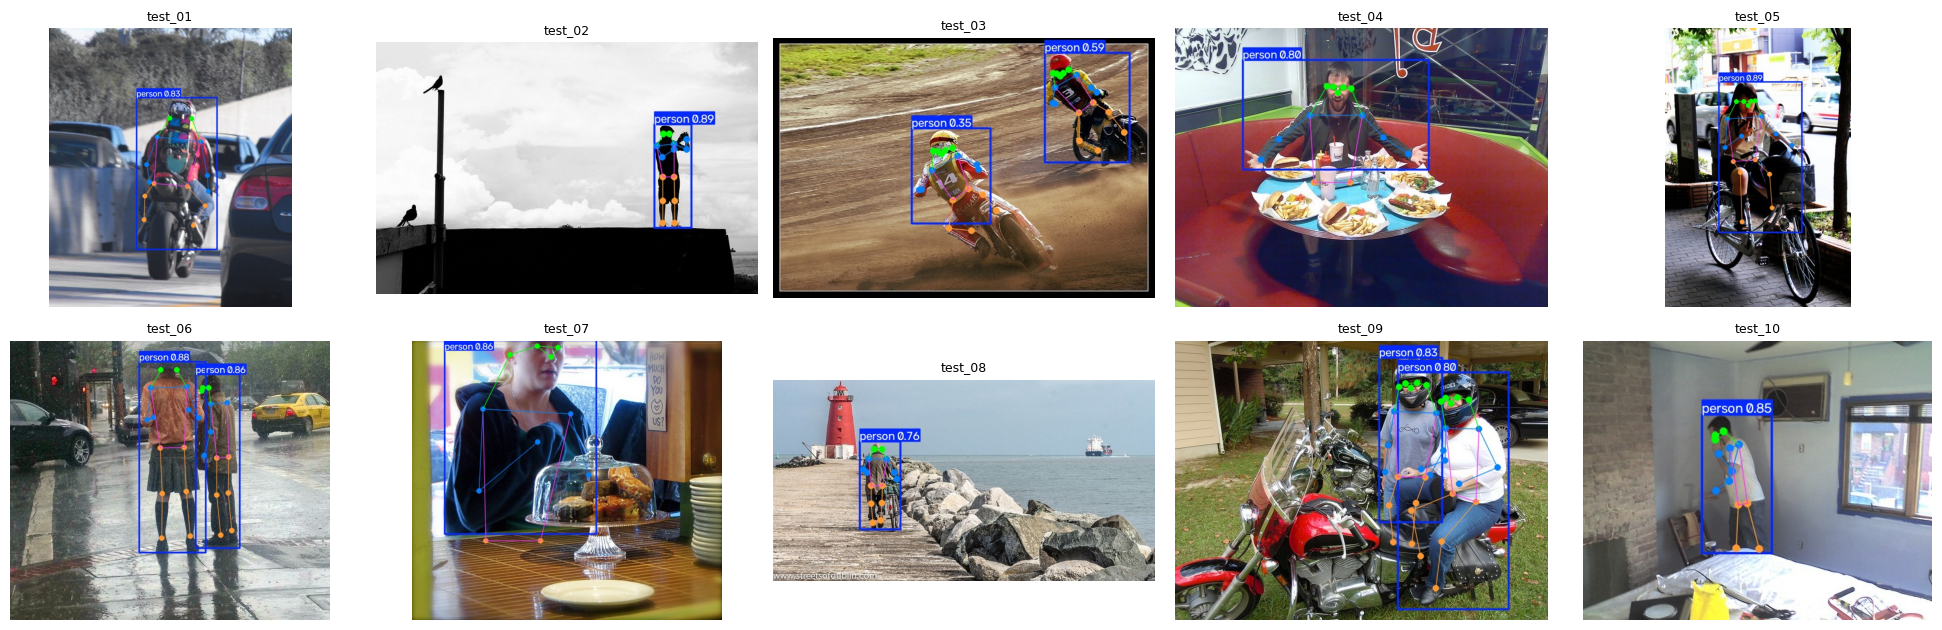

In [ ]:
import math

import matplotlib.pyplot as plt
from PIL import Image

PRED_DIR = RUNS / 'predictions'
best_model.predict(source=str(TEST_IMAGES), conf=0.25, device=DEVICE, save=True,
                   project=str(PRED_DIR), name='test', exist_ok=True)
predicted = sorted((PRED_DIR / 'test').glob('*.jpg'))

columns = 5
rows = math.ceil(len(predicted) / columns)
figure, axes = plt.subplots(rows, columns, figsize=(4 * columns, 3.2 * rows))
for axis, path in zip(axes.flat, predicted):
    axis.imshow(Image.open(path)); axis.set_title(path.stem, fontsize=9)
for axis in axes.flat:
    axis.axis('off')
plt.tight_layout(); plt.show()


## 6. Nhãn của bạn vs model chấm thử, trên chính tập train

Slide 27: model chấm thử **một lần để đối chiếu, không phải đáp án**. Bạn đã tự gán xong
và đã qua cổng gold rồi, nên bây giờ mới được nhìn.

Chỗ nào model và bạn lệch nhau nhiều: hoặc model sai (ảnh khó), hoặc nhãn của bạn sai
(và gold đã chỉ ra rồi). Ghi lại 2-3 ca vào báo cáo.


In [ ]:
from poselib import Person, greedy_match, image_size

OUT_OF_FRAME = 0
rows_out = []
for image_path in sorted(TRAIN_IMAGES.glob('*.jpg')):
    width, height = image_size(image_path)
    mine = parse_yolo_pose_file(TRAIN_LABELS / f'{image_path.stem}.txt')
    prediction = best_model.predict(source=str(image_path), conf=0.25, device=DEVICE, verbose=False)[0]
    theirs = []
    for box, keypoints in zip(prediction.boxes.xywhn.tolist(), prediction.keypoints.data.tolist()):
        points = [(x / width, y / height, 2 if score >= 0.5 else 1) if score > 0.05 else (0.0, 0.0, OUT_OF_FRAME)
                  for x, y, score in keypoints]
        theirs.append(Person(tuple(box), points))
    matched, extra, missed = greedy_match(theirs, mine, width, height)
    for _, _, score in matched:
        rows_out.append((image_path.stem, round(score, 3)))
    if extra or missed:
        rows_out.append((image_path.stem + ' (số người lệch)', f'model {len(theirs)} / bạn {len(mine)}'))

print(f"{'ảnh':<28}{'OKS model vs nhãn của bạn':>28}")
for stem, value in sorted(rows_out, key=lambda r: (isinstance(r[1], str), r[1])):
    print(f'{stem:<28}{value:>28}')
print('\nOKS thấp = model và bạn bất đồng. Xem lại ảnh đó bằng tools/visualize_pose.py.')


ảnh                            OKS model vs nhãn của bạn
train_01                                           0.502
train_15                                           0.505
train_16                                           0.688
train_14                                           0.711
train_06                                           0.757
train_15                                           0.776
train_01                                           0.826
train_12                                           0.828
train_03                                           0.842
train_08                                           0.847
train_10                                           0.859
train_04                                           0.881
train_04                                           0.886
train_13                                           0.899
train_20                                           0.899
train_11                                           0.916
train_16                       

## Câu hỏi phân tích để nộp

Trả lời trong `reports/REPORT.md`:

1. `pose_mAP50-95` thay đổi bao nhiêu sau fine-tune? Nếu nó **giảm**, hãy giải thích:
   20 ảnh của bạn dạy được model điều gì mà COCO chưa dạy, và nó làm hỏng điều gì?
2. `box_mAP` và `pose_mAP` chênh nhau bao nhiêu? Model tìm *người* dễ hơn hay tìm *khớp* dễ hơn?
3. Ở mục 5, tìm một ảnh model đoán sai. Gọi tên lỗi theo bốn loại của slide 43.
4. Ở mục 6, ảnh nào có OKS thấp nhất giữa bạn và model? Ai đúng - và bạn dựa vào đâu để nói vậy?
5. Trong `tools/evaluate_pose_annotations.py` bạn đã có OKS nhãn-của-bạn vs gold.
   Ảnh nào bạn gán tệ nhất *cũng* là ảnh model đoán tệ nhất? Nếu có, điều đó nói gì về ảnh đó?
